# AAMI 良率智能助手 MVP Demo
## 电镀工序高风险批次识别与原因解释

## 第 1 部分：项目背景
- 为什么从良率切入：良率是最直接的经营与质量指标，且 lot 级数据具备可操作性。
- 为什么不先做完整 MES：本 Demo 强调最小可用闭环，避免范围失控。
- 本次只做一个闭环：**数据 -> 风险识别 -> 原因解释 -> 建议动作 -> 回写入口**。

## 第 2 部分：场景故事
- AAMI 深圳工厂电镀车间，正常良率通常在 **96%–98%**。
- 当天已有异常批次：**LOT1006、LOT1007**。
- **LOT1008** 尚未完成终检（PENDING），但 AI 需要提前预警。

In [1]:
# 基础依赖
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

sys.path.append("../src")
from llm_provider import get_llm_provider, generate_lot_explanation, generate_action_advice

plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
# 数据文件准备：若不存在原始CSV，则自动创建
from pathlib import Path

raw_path = Path("../data/aami_yield_demo.csv")
clean_path = Path("../data/aami_yield_demo_clean.csv")
raw_path.parent.mkdir(parents=True, exist_ok=True)

if not raw_path.exists():
    rows = [
        ["HIST","LOT0918","M1","E01","Day",1,118,62,45.1,"MB01",97.4,0,"none","DONE"],
        ["HIST","LOT0919","M1","E01","Night",2,121,61,45.4,"MB01",97.0,0,"none","DONE"],
        ["HIST","LOT0920","M2","E02","Day",1,119,63,44.9,"MB02",96.8,0,"none","DONE"],
        ["HIST","LOT0921","M2","E03","Night",3,134,66,46.2,"MB02",91.4,1,"plating_void","DONE"],
        ["HIST","LOT0922","M1","E02","Day",2,120,62,45.0,"MB03",97.1,0,"none","DONE"],
        ["HIST","LOT0923","M3","E01","Night",1,122,61,45.3,"MB04",96.6,0,"none","DONE"],
        ["HIST","LOT0924","M3","E02","Day",2,118,60,44.8,"MB04",97.6,0,"none","DONE"],
        ["HIST","LOT0925","M2","E03","Night",2,132,65,46.0,"MB02",92.2,1,"burn_mark","DONE"],
        ["HIST","LOT0934","M2","E03","Night",4,136,67,46.4,"MB02",90.8,1,"edge_peeling","DONE"],
        ["HIST","LOT0945","M2","E03","Night",3,133,66,46.1,"MB07",91.7,1,"plating_void","DONE"],
        ["CURRENT","LOT1006","M2","E03","Night",3,137,67,46.5,"MB10",89.9,1,"burn_mark","DONE"],
        ["CURRENT","LOT1007","M2","E03","Night",4,135,66,46.3,"MB10",90.6,1,"edge_peeling","DONE"],
        ["CURRENT","LOT1008","M2","E03","Night",3,136,66,46.2,"MB11",None,None,None,"PENDING"],
        ["CURRENT","LOT1009","M1","E01","Day",1,120,61,45.0,"MB12",None,None,None,"PENDING"],
        ["CURRENT","LOT1010","M3","E02","Day",2,122,62,45.1,"MB13",None,None,None,"PENDING"],
    ]
    cols = ["record_type","lot_id","prod_model","machine_id","shift","setup_batch_seq","plating_current_a",
            "plating_time_s","bath_temp_c","material_batch","yield_pct","defect_flag","defect_type","inspection_status"]
    pd.DataFrame(rows, columns=cols).to_csv(raw_path, index=False)

# 清洗并保存 clean 版本
raw_df = pd.read_csv(raw_path)
for c in ["record_type","lot_id","prod_model","machine_id","shift","material_batch","defect_type","inspection_status"]:
    raw_df[c] = raw_df[c].astype(str).str.strip().replace({"nan": None})

for c in ["setup_batch_seq","plating_current_a","plating_time_s","bath_temp_c","yield_pct","defect_flag"]:
    raw_df[c] = pd.to_numeric(raw_df[c], errors="coerce")

raw_df.to_csv(clean_path, index=False)
print(f"已生成清洗数据: {clean_path}")

已生成清洗数据: ../data/aami_yield_demo_clean.csv


## 第 3 部分：数据预览
字段覆盖：record_type / lot_id / 设备 / 班次 / 电流 / 电镀时长 / 温度 / 良率 / 缺陷标记 / 检验状态。

In [3]:
df = pd.read_csv("../data/aami_yield_demo_clean.csv")
display(df.head(10))
print(df.dtypes)

,record_type,lot_id,prod_model,machine_id,shift,setup_batch_seq,plating_current_a,plating_time_s,bath_temp_c,material_batch,yield_pct,defect_flag,defect_type,inspection_status
0,HIST,LOT0918,M1,E01,Day,1,118,62,45.1,MB01,97.4,0.0,none,DONE
1,HIST,LOT0919,M1,E01,Night,2,121,61,45.4,MB01,97.0,0.0,none,DONE
2,HIST,LOT0920,M2,E02,Day,1,119,63,44.9,MB02,96.8,0.0,none,DONE
3,HIST,LOT0921,M2,E03,Night,3,134,66,46.2,MB02,91.4,1.0,plating_void,DONE
4,HIST,LOT0922,M1,E02,Day,2,120,62,45.0,MB03,97.1,0.0,none,DONE
5,HIST,LOT0923,M3,E01,Night,1,122,61,45.3,MB04,96.6,0.0,none,DONE
6,HIST,LOT0924,M3,E02,Day,2,118,60,44.8,MB04,97.6,0.0,none,DONE
7,HIST,LOT0925,M2,E03,Night,2,132,65,46.0,MB02,92.2,1.0,burn_mark,DONE
8,HIST,LOT0926,M1,E01,Day,3,119,62,45.2,MB05,97.3,0.0,none,DONE
9,HIST,LOT0927,M3,E02,Night,1,123,63,45.1,MB06,96.4,0.0,none,DONE


record_type           object
lot_id                object
prod_model            object
machine_id            object
shift                 object
setup_batch_seq        int64
plating_current_a      int64
plating_time_s         int64
bath_temp_c          float64
material_batch        object
yield_pct            float64
defect_flag          float64
defect_type           object
inspection_status     object
dtype: object


## 第 4 部分：先看现象，不急着上 AI

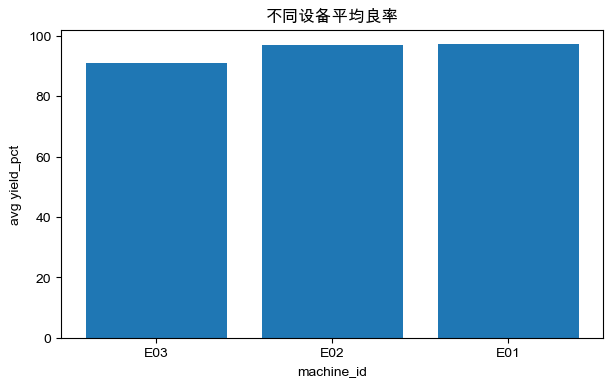

In [4]:
# ========== 解决中文显示 ==========
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 自带中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# ================================
obs = df[df["inspection_status"] == "DONE"].copy()

# 图1：不同设备平均良率
machine_mean = obs.groupby("machine_id")["yield_pct"].mean().sort_values()
plt.figure(); plt.bar(machine_mean.index, machine_mean.values)
plt.title("不同设备平均良率")
plt.xlabel("machine_id"); plt.ylabel("avg yield_pct")
plt.show()

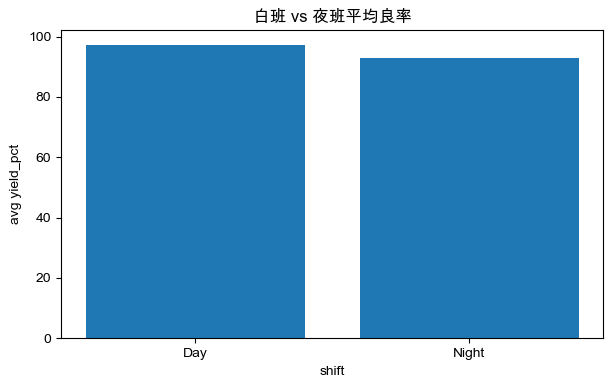

In [5]:
# 图2：白班 vs 夜班
# ========== 解决中文显示 ==========
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 自带中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# ================================
shift_mean = obs.groupby("shift")["yield_pct"].mean().reindex(["Day","Night"])
plt.figure(); plt.bar(shift_mean.index, shift_mean.values)
plt.title("白班 vs 夜班平均良率")
plt.xlabel("shift"); plt.ylabel("avg yield_pct")
plt.show()

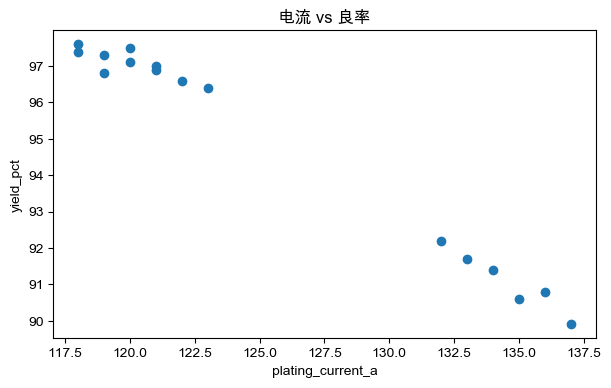

In [6]:
# 图3：电流 vs 良率
# ========== 解决中文显示 ==========
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 自带中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# ================================
plt.figure(); plt.scatter(obs["plating_current_a"], obs["yield_pct"])
plt.title("电流 vs 良率")
plt.xlabel("plating_current_a"); plt.ylabel("yield_pct")
plt.show()

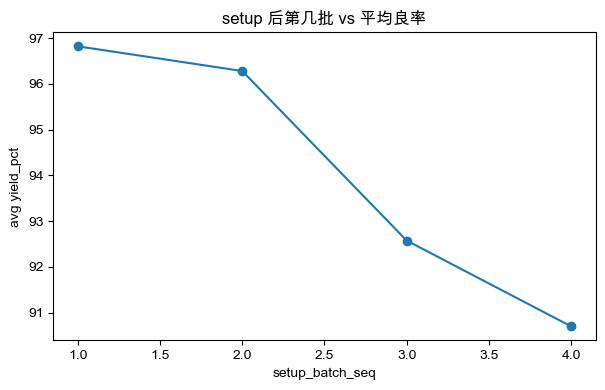

观察总结：E03、Night、高电流区间对应更低良率，且与已知异常批次特征一致。


In [7]:
# 图4：setup 后第几批 vs 良率
# ========== 解决中文显示 ==========
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 自带中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# ================================
seq_mean = obs.groupby("setup_batch_seq")["yield_pct"].mean()
plt.figure(); plt.plot(seq_mean.index, seq_mean.values, marker="o")
plt.title("setup 后第几批 vs 平均良率")
plt.xlabel("setup_batch_seq"); plt.ylabel("avg yield_pct")
plt.show()

print("观察总结：E03、Night、高电流区间对应更低良率，且与已知异常批次特征一致。")

## 第 5 部分：定义 AI 任务
- 本 Demo 不做全厂优化。
- 任务聚焦：识别 **高风险 lot**，尤其是当前尚未终检的 PENDING lot。

## 第 6 部分：本地风险模型
使用 HIST 数据训练一个稳妥可复现的二分类模型，输出 risk_score 与 risk_level。

In [8]:
train_df = df[df["record_type"] == "HIST"].copy()
train_df["target"] = (train_df["defect_flag"] == 1).astype(int)

feature_cols = ["machine_id", "shift", "setup_batch_seq", "plating_current_a", "plating_time_s", "bath_temp_c"]
cat_cols = ["machine_id", "shift"]
num_cols = [c for c in feature_cols if c not in cat_cols]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=200, class_weight="balanced", random_state=42)),
])

model.fit(train_df[feature_cols], train_df["target"])

current_pending = df[(df["record_type"] == "CURRENT") & (df["inspection_status"] == "PENDING")].copy()
current_pending["risk_score"] = model.predict_proba(current_pending[feature_cols])[:, 1]

# 阈值按演示可解释性设定：>=0.60 为高风险
current_pending["risk_level"] = np.where(current_pending["risk_score"] >= 0.60, "HIGH", "LOW")

display(current_pending[["lot_id", "machine_id", "shift", "plating_current_a", "risk_score", "risk_level"]].sort_values("risk_score", ascending=False))

assert current_pending.loc[current_pending["lot_id"] == "LOT1008", "risk_level"].iloc[0] == "HIGH", "LOT1008 需要被识别为高风险"
print("校验通过：LOT1008 已识别为高风险")

,lot_id,machine_id,shift,plating_current_a,risk_score,risk_level
16,LOT1008,E03,Night,136,0.998899,HIGH
18,LOT1010,E02,Day,122,0.018780,LOW
17,LOT1009,E01,Day,120,0.003676,LOW


校验通过：LOT1008 已识别为高风险


## 第 7 部分：LLM 解释层（支持开关）

In [9]:
# ===== LLM 解释开关 =====
# USE_LLM: 总开关，False 时强制走本地模板（用于演示兜底）。
USE_LLM = True
# LLM_PROVIDER: 可选 auto/openai/gemini/ollama/local。
# - auto: 按 provider 链优先级自动尝试
# - 指定 provider: 会先尝试指定项，失败后再回退
LLM_PROVIDER = "auto"   # auto / openai / gemini / ollama / local

# get_llm_provider 仅做“预估可用 provider”展示。
# 实际使用的 provider 以后续 explanation/actions 返回值中的 provider 字段为准。
resolved_provider = get_llm_provider(provider=LLM_PROVIDER, use_llm=USE_LLM)
provider_cn = {
    "openai": "OpenAI 生成",
    "gemini": "Gemini 生成",
    "ollama": "Ollama 本地模型生成",
    "local": "本地模板生成",
}.get(resolved_provider, "本地模板生成")
print(f"当前解释方式（预估）：{provider_cn}")
print("说明：最终实际 provider 请以后续结果中的 provider 字段为准。")


当前解释方式（预估）：Ollama 本地模型生成
说明：最终实际 provider 请以后续结果中的 provider 字段为准。


In [10]:
# 选取高风险 lot（LOT1008）作为解释演示对象。
lot1008 = current_pending[current_pending["lot_id"] == "LOT1008"].iloc[0].to_dict()

# 构造历史相似案例，增强解释可读性（并非必须字段，但更贴近工程复盘语境）。
similar_cases = (
    df[(df["record_type"] == "HIST") & (df["lot_id"].isin(["LOT0921", "LOT0934", "LOT0945"]))]
    [["lot_id", "machine_id", "shift", "plating_current_a", "yield_pct", "defect_type"]]
    .to_dict(orient="records")
)

# 调用统一解释接口：内部会按 provider 链路尝试，并自动附带调试字段。
explanation = generate_lot_explanation(
    lot_features=lot1008,
    similar_cases=similar_cases,
    provider=LLM_PROVIDER,
    use_llm=USE_LLM,
)

# 1) 结构化 JSON 输出（便于保存/追踪）。
print("LOT1008 风险解释（结构化 JSON）")
print(json.dumps(explanation, ensure_ascii=False, indent=2))

# 2) 调试信息输出（用于快速定位到底是哪一层失败）。
print()
print("[调试信息] 风险解释")
print("实际 provider:", explanation.get("provider"))
print("尝试 provider:", explanation.get("attempted_provider"))
print("是否回退:", explanation.get("fallback_used"))
print("回退原因:", explanation.get("fallback_reason"))
print("错误:", explanation.get("error"))

# 3) 人类可读摘要（客户演示时更直观）。
print()
print("LOT1008 风险解释（可读摘要）")
print(f"- 风险摘要: {explanation.get('risk_summary', 'N/A')}")
for i, reason in enumerate(explanation.get('key_reasons', [])[:5], 1):
    print(f"  {i}. {reason}")


OLLAMA DEBUG:
url: http://localhost:11434/api/chat
model: gemma4:e4b
timeout: 120.0
LOT1008 风险解释（结构化 JSON）
{
  "lot_id": "LOT1008",
  "risk_summary": "当前批次风险等级高，需重点关注电镀工艺参数与历史异常批次的一致性。",
  "key_reasons": [
    "风险评分极高（0.9989），需立即介入分析。",
    "设备E03在夜班运行，历史记录存在类似异常。",
    "当前电流值偏高，与历史低良率批次特征吻合。"
  ],
  "similar_cases": [
    "LOT0921 (E03, Night, Void)",
    "LOT0934 (E03, Night, Edge Peeling)",
    "LOT0945 (E03, Night, Void)"
  ],
  "tone": "警示",
  "actions": [
    "立即复核E03夜班的电镀电流设定值。",
    "对比当前工艺参数与LOT0921/LOT0945的差异。",
    "安排工艺工程师对当前批次进行人工抽检。"
  ],
  "provider": "ollama",
  "attempted_provider": "auto",
  "fallback_used": true,
  "fallback_reason": "openai sdk not installed",
  "error": "",
  "raw_text": "```json\n{\n  \"lot_id\": \"LOT1008\",\n  \"risk_summary\": \"当前批次风险等级高，需重点关注电镀工艺参数与历史异常批次的一致性。\",\n  \"key_reasons\": [\n    \"风险评分极高（0.9989），需立即介入分析。\",\n    \"设备E03在夜班运行，历史记录存在类似异常。\",\n    \"当前电流值偏高，与历史低良率批次特征吻合。\"\n  ],\n  \"similar_cases\": [\n    \"LOT0921 (E03, Night, Void

## 第 8 部分：建议动作（建议，不自动执行）

In [11]:
# 调用建议动作接口：同样包含 provider/fallback/error 等调试字段。
actions = generate_action_advice(
    lot_features=lot1008,
    provider=LLM_PROVIDER,
    use_llm=USE_LLM,
)

# 1) 结构化 JSON 输出。
print("LOT1008 建议动作（结构化 JSON）")
print(json.dumps(actions, ensure_ascii=False, indent=2))

# 2) 调试信息输出。
print()
print("[调试信息] 建议动作")
print("实际 provider:", actions.get("provider"))
print("尝试 provider:", actions.get("attempted_provider"))
print("是否回退:", actions.get("fallback_used"))
print("回退原因:", actions.get("fallback_reason"))
print("错误:", actions.get("error"))

# 强调“仅建议不自动执行”，符合工程安全治理要求。
print()
print("说明：以上为建议动作，不自动执行，需工程师确认。")


OLLAMA DEBUG:
url: http://localhost:11434/api/chat
model: gemma4:e4b
timeout: 120.0
LOT1008 建议动作（结构化 JSON）
{
  "lot_id": "LOT1008",
  "advice_level": "HIGH",
  "actions": [
    "加严对当前批次电镀件的目检频率。",
    "重点检查设备E03的电镀槽和电极连接。",
    "复核并确认当前电镀电流设置是否准确。"
  ],
  "note": "当前批次风险评分极高，需立即采取措施进行工艺复核和质量控制加强。",
  "key_reasons": [
    "风险评分接近1.0，预示工艺稳定性存在重大隐患。",
    "当前电镀参数（如电流、温度）的波动需重点关注。",
    "良率数据缺失，无法进行有效良率趋势分析。"
  ],
  "risk_summary": "高风险。需立即对设备E03的运行状态、电镀参数的设定值进行全面排查，防止大面积报废。",
  "provider": "ollama",
  "attempted_provider": "auto",
  "fallback_used": true,
  "fallback_reason": "openai sdk not installed",
  "error": "",
  "raw_text": "```json\n{\n  \"lot_id\": \"LOT1008\",\n  \"advice_level\": \"HIGH\",\n  \"actions\": [\n    \"加严对当前批次电镀件的目检频率。\",\n    \"重点检查设备E03的电镀槽和电极连接。\",\n    \"复核并确认当前电镀电流设置是否准确。\"\n  ],\n  \"note\": \"当前批次风险评分极高，需立即采取措施进行工艺复核和质量控制加强。\",\n  \"key_reasons\": [\n    \"风险评分接近1.0，预示工艺稳定性存在重大隐患。\",\n    \"当前电镀参数（如电流、温度）的波动需重点关注。\",\n    \"良率数据缺失，无法进行有效良率趋势分析。\"\n  ],\n  \"

## 第 9 部分：闭环总结
**最小闭环：**
历史数据 -> 风险识别 -> 原因解释 -> 建议动作 -> 工程师确认 -> 结果回写 -> 持续学习

**产品化总结：**
> AI 不只是报表，它开始具备像工程师一样看 lot 风险的能力。